# Global Patent Intelligence — Data Exploration
Visualisations from the cleaned PatentsView dataset (500k rows per file).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
CLEAN_DIR = Path("../data/clean")
NROWS = 500_000

patents       = pd.read_csv(CLEAN_DIR / "clean_patents.csv",       usecols=["patent_id","year","abstract"], nrows=NROWS, low_memory=False)
inventors     = pd.read_csv(CLEAN_DIR / "clean_inventors.csv",     usecols=["inventor_id","name","country"], nrows=NROWS)
companies     = pd.read_csv(CLEAN_DIR / "clean_companies.csv",     usecols=["company_id","name"], nrows=NROWS)
relationships = pd.read_csv(CLEAN_DIR / "clean_relationships.csv", usecols=["patent_id","inventor_id","company_id"], nrows=NROWS)
locations     = pd.read_csv(CLEAN_DIR / "clean_locations.csv",     usecols=["location_id","country"])

# Load full year column for accurate year charts
all_years = pd.read_csv(CLEAN_DIR / "clean_patents.csv", usecols=["year"], low_memory=False)

print(f"Patents:       {len(patents):,}")
print(f"Inventors:     {len(inventors):,}")
print(f"Companies:     {len(companies):,}")
print(f"Relationships: {len(relationships):,}")
print(f"All years:     {len(all_years):,}")

Patents:       500,000
Inventors:     500,000
Companies:     500,000
Relationships: 500,000
Locations:     100,452


## 1. Patent Volume Trend by Year

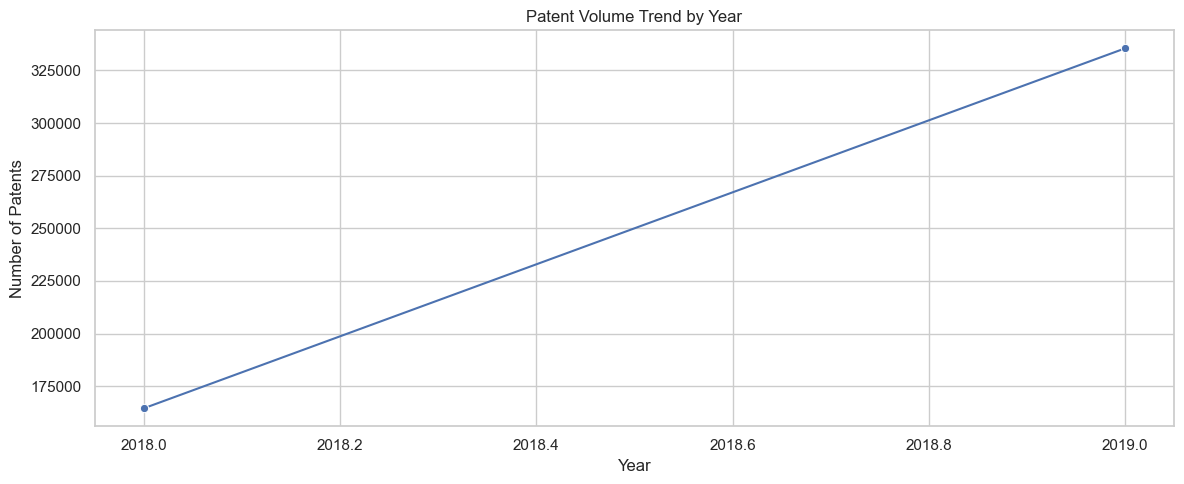

In [2]:
trend = all_years.dropna().groupby("year").size().reset_index(name="patent_count")
plt.figure(figsize=(12, 5))
sns.lineplot(data=trend, x="year", y="patent_count", marker="o")
plt.title("Patent Volume Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Patents")
plt.tight_layout()
plt.show()

## 2. Top 15 Inventors by Patent Count

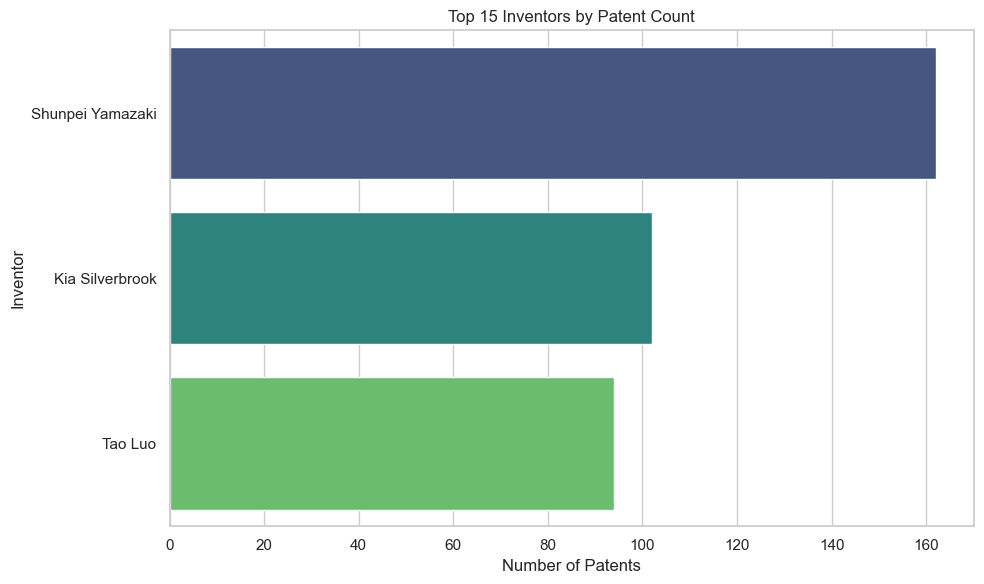

In [3]:
top_inventors = relationships.groupby("inventor_id").patent_id.nunique().reset_index()
top_inventors = top_inventors.merge(inventors[["inventor_id", "name"]].drop_duplicates(subset="inventor_id"), on="inventor_id", how="left")
top_inventors = top_inventors.rename(columns={"patent_id": "patent_count"})
top_inventors = top_inventors.sort_values("patent_count", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_inventors, x="patent_count", y="name",
            hue="name", palette="viridis", legend=False)
plt.title("Top 15 Inventors by Patent Count")
plt.xlabel("Number of Patents")
plt.ylabel("Inventor")
plt.tight_layout()
plt.show()

## 3. Top 15 Companies by Patent Count

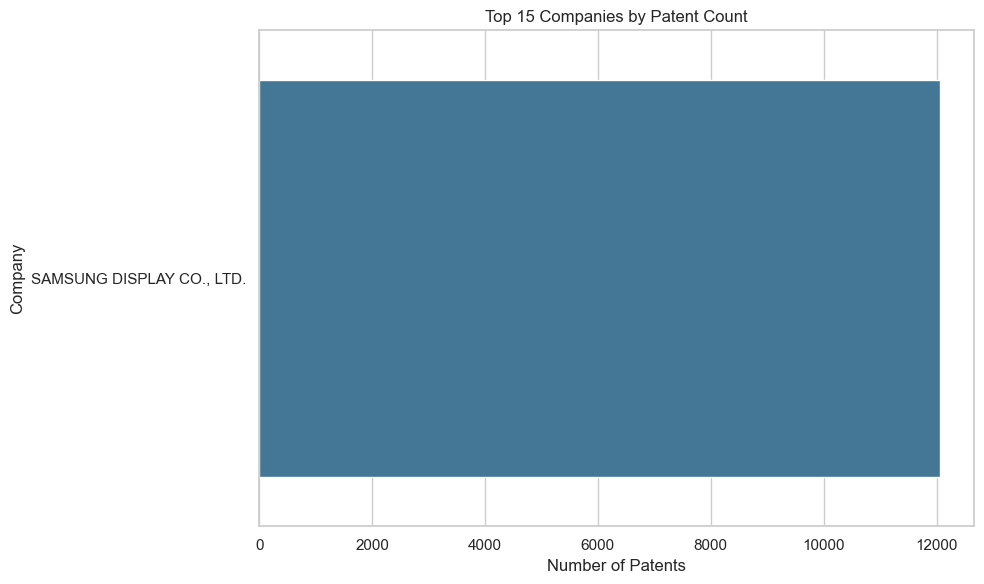

In [4]:
top_companies = relationships.groupby("company_id").patent_id.nunique().reset_index()
top_companies = top_companies.merge(companies[["company_id", "name"]].drop_duplicates(subset="company_id"), on="company_id", how="left")
top_companies = top_companies.rename(columns={"patent_id": "patent_count"})
top_companies = top_companies.sort_values("patent_count", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_companies, x="patent_count", y="name",
            hue="name", palette="mako", legend=False)
plt.title("Top 15 Companies by Patent Count")
plt.xlabel("Number of Patents")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

## 4. Top 15 Countries by Patent Count

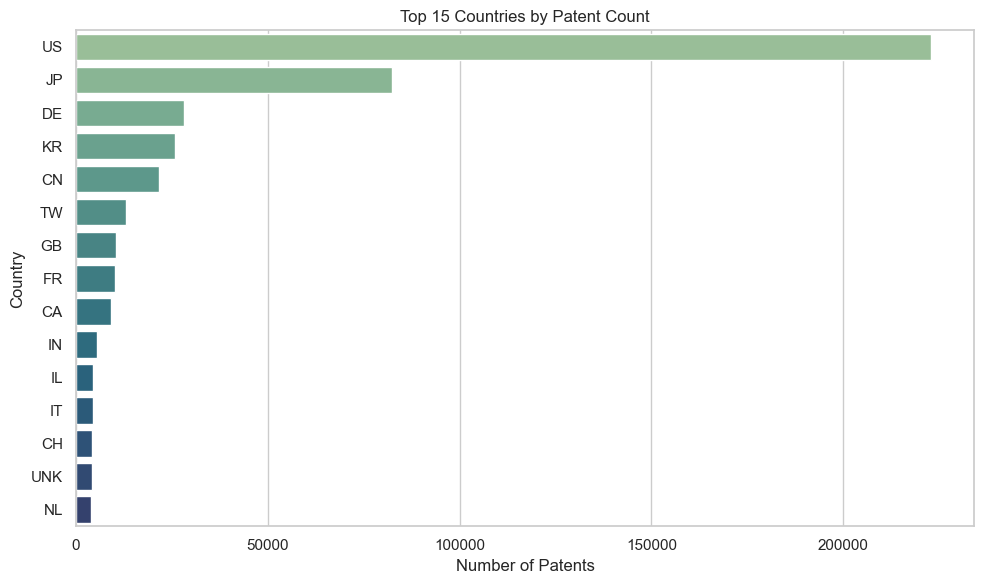

In [5]:
country_data = relationships.merge(inventors[["inventor_id", "country"]].drop_duplicates(subset="inventor_id"), on="inventor_id", how="left")
country_counts = (
    country_data.groupby("country").patent_id.nunique()
    .reset_index(name="patent_count")
    .sort_values("patent_count", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=country_counts, x="patent_count", y="country",
            hue="country", palette="crest", legend=False)
plt.title("Top 15 Countries by Patent Count")
plt.xlabel("Number of Patents")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## 6. Distribution of Patent Abstract Lengths

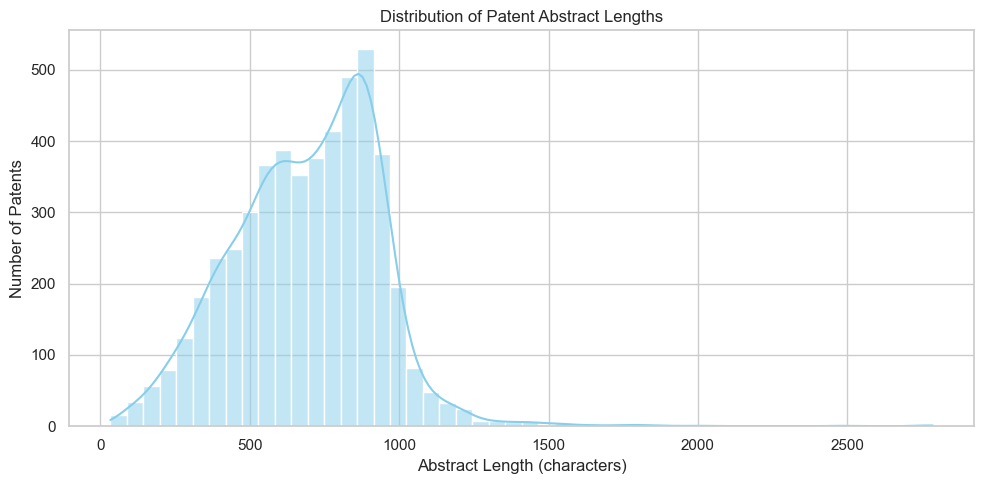

In [7]:
patents["abstract_length"] = patents["abstract"].astype(str).str.len()
sample_abs = patents["abstract_length"].sample(n=min(5000, len(patents)), random_state=42)

plt.figure(figsize=(10, 5))
sns.histplot(sample_abs, bins=50, kde=True, color="skyblue")
plt.title("Distribution of Patent Abstract Lengths")
plt.xlabel("Abstract Length (characters)")
plt.ylabel("Number of Patents")
plt.tight_layout()
plt.show()

## 7. Top 15 Most Recent Years by Patent Count

In [9]:
recent = all_years["year"].value_counts().sort_index(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=recent.values, y=recent.index.astype(str),
            hue=recent.index.astype(str), palette="flare", legend=False)
plt.title("Top 15 Most Recent Years by Patent Count")
plt.xlabel("Number of Patents")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

NameError: name 'all_years' is not defined